#### Name: Jon Stowers

# PHYS 230 Lab Assignment 14

### Monday, March 30, 2026: Chapter 8.1
- First-order differential equations 

In [1]:
# import statements here
import numpy as np
import matplotlib.pyplot as plt


### The problem:

Today we will solve a first-order ordinary differential equation for the velocity of a falling ball with air resistance (assuming linear drag). This equation, assuming vertical motion only and downwards as the positive y-direction, is given as: 

$$\frac{dv}{dt}= g -\frac{b}{m}v $$

The exact solution to this differential equation is: 

$$ v(t) = v_0 e^{-\frac{b}{m}t} + v_{\text{ter}} \left( 1 -  e^{-\frac{b}{m}t} \right) $$


where $v_0$ is the initial velocity and $v_{\text{ter}} = \frac{mg}{b}$ is the terminal velocity. For this problem, we will assume that our 1.0 kg ball is initially at rest, so $v_0 = 0$ at $t=0$, the graviational acceleration $g = 9.8 \text{ m/s}^2$, and the drag coefficient $b = 0.1 \frac{\text{N}}{\text{m/s}}$. 

*don't forget comments in your code cells*

### Part 1: Exact Solution

Calculate the exact solution of $v(t)$ for an array of times. Do this in the following steps: 

#### Step 1: 

Write a function `v(t,b,m,v0)` that takes in an array of times (from $t=0$ to $t=100$ by 2's) and constants $b,m,v_0$ and returns an array of velocities using the equation above. Think about any constants might need to be included inside the function. 

In [5]:
#define constants
g = 9.8 #m/s^2
m = 1.0 #kg

v0 = 0 #initially at rest

b = 0.1 #N/m/s


#define equation for exact solution
def v(t,b,m,v0):
    return v0*np.exp(-t*b/m) + (m*g/b) * (1-np.exp(-t*b/m))






### <font color='purple'> Comments </font> 

<font color='purple'> good but constants should be decided in the next step</font> 


#### Step 2: 

Define the array of times $t$, or whatever variable you want to use, and your necessary constants, and calculate the array of velocities using your function. 

In [6]:
exacttpoints = np.arange(0,100,2) #range of times
exactvpoints = np.zeros(len(exacttpoints)) #will be populated with velocities for each time

exactvpoints = v(exacttpoints,b,m,v0) #populating velocities


### <font color='purple'> Comments </font> 

<font color='purple'>why is `exactvpoints` defined twice here? I don't understand? I don't think you use it? 

Also, should have moved constants to here  </font> 


#### Step 3: 
Make a plot of the results. 

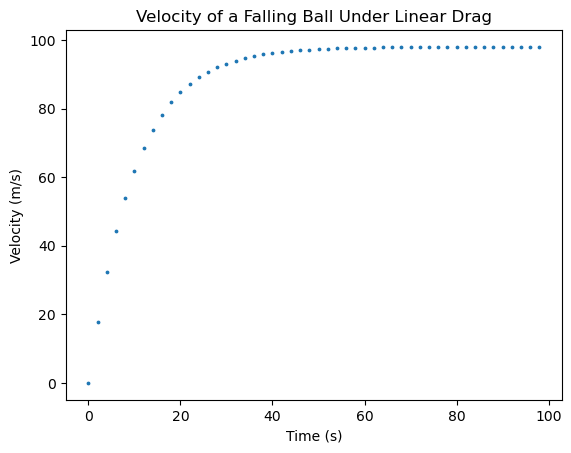

In [7]:
plt.scatter(exacttpoints,exactvpoints,s=3)
plt.title('Velocity of a Falling Ball Under Linear Drag')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.show()

### <font color='purple'> Comments </font> 

<font color='purple'> nicely formatted plot - any comments?  </font> 


### Part 2: Euler Method

Calculate the solution for the same array of times using the Euler method instead. 

#### Step 1: 

Write two functions: `f(v)` that calculate the result of the differential equation for vertical, linear projectile motion, and `euler(t,h,v0,f)` that takes in an array $t$ of times in the same range as part 1 and using a defined $h$ value,initial conditions, and the differential equation returns an *array*. 

In [ ]:
#define constants
g = 9.8 #m/s^2
m = 1.0 #kg

v0 = 0 #initially at rest

b = 0.1 #N/m/s

#define functions
def f(v):
    return g - (b/m)*v

eulertpoints = np.arange(0,100,2) #range of times
h = (100-0)/len(eulertpoints)


def euler(t,h,v0,f):
    vpoints = np.zeros(len(t))
    v = v0 #initial condition before for loop
    for i in range(len(t)):
        vpoints[i] = v
        v += h*f(v)
    return vpoints    



#### Step 2

Calculate the array of velocities usig your `euler` function and make a plot of the results with the exact calculation on the **same** graph (put both results on the same graph here).

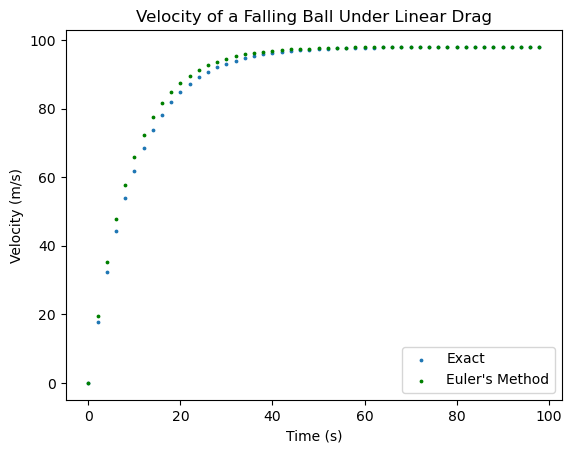

In [9]:

eulervpoints = euler(eulertpoints,h,v0,f)

plt.scatter(exacttpoints,exactvpoints,s=3,label='Exact')
plt.scatter(eulertpoints,eulervpoints,s=3,c='g',label='Euler\'s Method')
plt.title('Velocity of a Falling Ball Under Linear Drag')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.legend()
plt.show()

### <font color='purple'> Comments </font> 

<font color='purple'>good job, but could use a bit more expalnation, through comments, along the way of what is going on. How does the euler method work? what is going on in the cell where you create eulervpoints and then graph things? what is being graphed? 

nice graph with legend!  </font> 


### Part 3: Fourth-order Runge-Kutta Method

Calculate the solution for the same array of times using the Runge-Kutta method instead. For this, define a function `RK4(t,h,v0,f)` that takes in an array of times, initial velocity, $h$, initial conditions, and differential equation function. 

Plot this as well as the exact and Euler solutions on the **same** graph as well. 

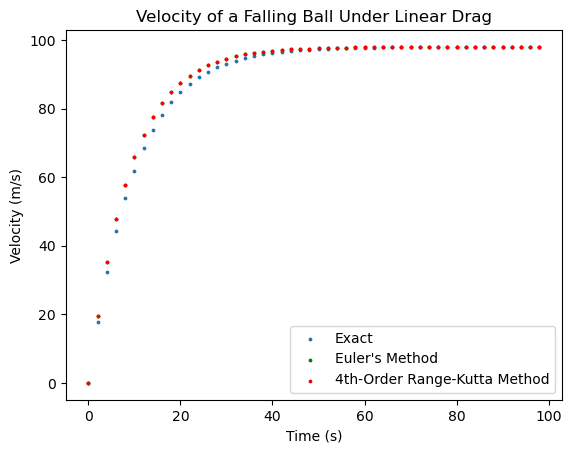

In [11]:
#define constants
g = 9.8 #m/s^2
m = 1.0 #kg

v0 = 0 #initially at rest

b = 0.1 #N/m/s

#define functions
def f(v):
    return g - (b/m)*v


rktpoints = np.arange(0,100,2) #range of times
h = (100-0)/len(rktpoints)


def rk4(t,h,v0,f):
    vpoints = np.zeros(len(t))
    v = v0 #initial condition before for loop
    for i in range(len(t)):
        vpoints[i] = v
        k1 = h*f(v)
        k2 = h*f(v+0.5*k1)
        k3 = h*f(v+0.5*k2)
        k4 = h*f(v+k3)
        v += (1/6)*(k1 + 2*k2 + 2*k3 + k4)
    return vpoints    

rkvpoints = euler(rktpoints,h,v0,f)

plt.scatter(exacttpoints,exactvpoints,s=3,label='Exact')
plt.scatter(eulertpoints,eulervpoints,s=3,c='g',label='Euler\'s Method')
plt.scatter(rktpoints,rkvpoints,s=3,c='r',label='4th-Order Range-Kutta Method')
plt.title('Velocity of a Falling Ball Under Linear Drag')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.legend()
plt.show()




### <font color='purple'> Comments </font> 

<font color='purple'> good! but could use just bit more commenting. Nice application and graphing!  </font> 


### Part 4: Markdown comparision

What can you conclude about the results? Do they all agree? (Explain in a markdown cell below - you will need to change it to a markdown cell first)

The computational results for the Euler's Method and the 4th-order Range-Kutta Method are so close that they overlap one another on the graph. With 50 points (range of 0-100 and a step size of 2), both methods have about the same accuracy. Their approximations are both evident, though, between 20 and 40 seconds, where the exponential function flattens out as it approaches terminal velocity. While both methods approximate the exact results very closely at small times and at large times, they are most inaccurate when the slope of the function is changing the most. Despite these methods' not perfectly approximating at the 20-40 second time window, I think both sets of results do agree with the expected solution.

### Part 5: Adjust

Try using smaller and bigger time steps to see the effect of improving your approximations (Euler and/or Runge-Kutta). Explain your results and process in markdown. 

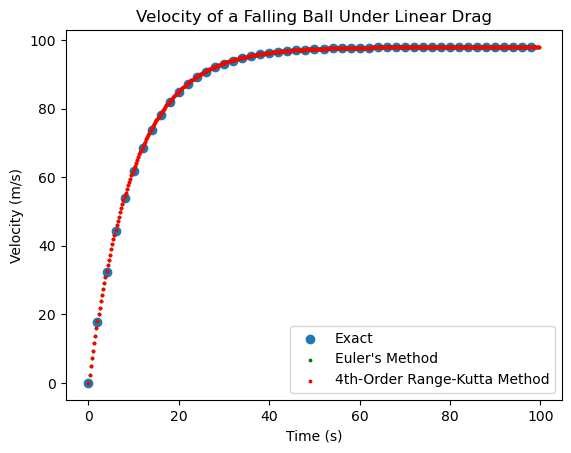

In [21]:
#define constants
g = 9.8 #m/s^2
m = 1.0 #kg

v0 = 0 #initially at rest

b = 0.1 #N/m/s

#define functions
def f(v):
    return g - (b/m)*v


eulertpoints = np.arange(0,100,0.25) #range of times
h = (100-0)/len(eulertpoints)







def euler(t,h,v0,f):
    vpoints = np.zeros(len(t))
    v = v0 #initial condition before for loop
    for i in range(len(t)):
        vpoints[i] = v
        v += h*f(v)
    return vpoints  

eulervpoints = euler(eulertpoints,h,v0,f)

rktpoints = np.arange(0,100,0.25) #range of times
h = (100-0)/len(rktpoints)


def rk4(t,h,v0,f):
    vpoints = np.zeros(len(t))
    v = v0 #initial condition before for loop
    for i in range(len(t)):
        vpoints[i] = v
        k1 = h*f(v)
        k2 = h*f(v+0.5*k1)
        k3 = h*f(v+0.5*k2)
        k4 = h*f(v+k3)
        v += (1/6)*(k1 + 2*k2 + 2*k3 + k4)
    return vpoints    

rkvpoints = euler(rktpoints,h,v0,f)

plt.scatter(exacttpoints,exactvpoints,label='Exact')
plt.scatter(eulertpoints,eulervpoints,s=3,c='g',label='Euler\'s Method')
plt.scatter(rktpoints,rkvpoints,s=3,c='r',label='4th-Order Range-Kutta Method')
plt.title('Velocity of a Falling Ball Under Linear Drag')
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.legend()
plt.show()

#### Explanation Markdown Cell: 

Halving the step size to 1 second causes both Methods to match quite closely, but not perfectly closely. Halving the step size twice more, to 0.25 seconds, generates the above graph, where both Methods match the exact values very closely, even through the areas where the step size of 2 did not match closely in the earlier part.

### <font color='purple'> Comments </font> 

<font color='purple'>I only see one result here? where are your other step size results? </font> 
